# Homework 6 — Spring 2026
**Author:** Justin Zhang  
**Due:** April 13, 2026

This notebook contains two parts:
1. **Part 1 — Reinforcement Learning:** Value Iteration on a FrozenLake-style grid world MDP.
2. **Part 2 — Mini Research Task:** Diffusion models — comparing the number of denoising steps using a pretrained Stable Diffusion / DDPM pipeline (with a minimal from-scratch 1D diffusion demo as a fallback).

---

# Part 1 — Value Iteration on a Grid World MDP (40 pts)

## 1.1 MDP Definition

I use a 4x4 FrozenLake-style grid world. The agent starts at the top-left cell `S` and must reach the goal `G` in the bottom-right. Certain cells are holes `H` that terminate the episode with a reward of 0. Reaching the goal gives reward +1. All other transitions give reward 0.

- **State space** $\mathcal{S}$: 16 discrete states, one per cell of the 4x4 grid (indexed 0..15, row-major).
- **Action space** $\mathcal{A}$: 4 discrete actions — `0=Left, 1=Down, 2=Right, 3=Up`.
- **Transition dynamics** $P(s'\mid s,a)$: Stochastic ("slippery"). With probability 1/3 the agent moves in the intended direction, and with probability 1/3 each it slips to one of the two perpendicular directions. Moves off the grid leave the agent in place. Holes and the goal are absorbing.
- **Reward** $R(s,a,s')$: +1 when transitioning into the goal cell, 0 otherwise.
- **Discount factor** $\gamma$: default 0.9, varied below.

This is an MDP because: (i) the state fully summarizes the history relevant to future rewards (Markov property — next state depends only on the current state and action), (ii) transitions and rewards are stationary probability distributions, and (iii) the agent chooses actions to maximize expected discounted return.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# Map legend: S=start, F=frozen, H=hole, G=goal
MAP = [
    "SFFF",
    "FHFH",
    "FFFH",
    "HFFG",
]
N_ROWS, N_COLS = 4, 4
N_STATES = N_ROWS * N_COLS
N_ACTIONS = 4  # 0=L, 1=D, 2=R, 3=U
ACTION_NAMES = ["L", "D", "R", "U"]
ACTION_ARROWS = ["\u2190", "\u2193", "\u2192", "\u2191"]

def rc(s):
    return s // N_COLS, s % N_COLS

def idx(r, c):
    return r * N_COLS + c

def step(r, c, a):
    if a == 0:   # Left
        c = max(c - 1, 0)
    elif a == 1: # Down
        r = min(r + 1, N_ROWS - 1)
    elif a == 2: # Right
        c = min(c + 1, N_COLS - 1)
    elif a == 3: # Up
        r = max(r - 1, 0)
    return r, c

def build_mdp(slip_prob=2/3):
    """Return P[s,a] -> list of (prob, next_state, reward, done).

    slip_prob is the total probability of NOT going in the intended direction;
    it is split evenly across the two perpendicular directions.
    With slip_prob=2/3 we recover classic slippery FrozenLake (1/3 each among
    intended + two perpendicular).
    """
    P = {s: {a: [] for a in range(N_ACTIONS)} for s in range(N_STATES)}
    perp = {0: [1, 3], 1: [0, 2], 2: [1, 3], 3: [0, 2]}  # perpendicular actions
    for s in range(N_STATES):
        r, c = rc(s)
        tile = MAP[r][c]
        for a in range(N_ACTIONS):
            if tile in ("H", "G"):
                # Absorbing terminal state: self-loop with 0 reward.
                P[s][a].append((1.0, s, 0.0, True))
                continue
            outcomes = [(1 - slip_prob, a)] + [(slip_prob / 2.0, ap) for ap in perp[a]]
            for prob, act in outcomes:
                nr, nc = step(r, c, act)
                ns = idx(nr, nc)
                ntile = MAP[nr][nc]
                reward = 1.0 if ntile == "G" else 0.0
                done = ntile in ("H", "G")
                P[s][a].append((prob, ns, reward, done))
    return P

P = build_mdp()
print("Example transitions from state 0 (start), action Right:")
for prob, ns, r, d in P[0][2]:
    print(f"  p={prob:.3f}  next_state={ns}  reward={r}  done={d}")

Example transitions from state 0 (start), action Right:
  p=0.333  next_state=1  reward=0.0  done=False
  p=0.333  next_state=4  reward=0.0  done=False
  p=0.333  next_state=0  reward=0.0  done=False


## 1.2 Value Iteration

Value iteration applies the Bellman optimality operator until convergence:
$$ V_{k+1}(s) = \max_{a} \sum_{s'} P(s'\mid s,a)\left[R(s,a,s') + \gamma V_k(s')\right]. $$
The greedy policy with respect to the converged $V^*$ is optimal.

In [2]:
def value_iteration(P, gamma=0.9, tol=1e-9, max_iters=10_000):
    V = np.zeros(N_STATES)
    for it in range(max_iters):
        V_new = np.zeros_like(V)
        for s in range(N_STATES):
            q_vals = np.zeros(N_ACTIONS)
            for a in range(N_ACTIONS):
                q = 0.0
                for prob, ns, r, done in P[s][a]:
                    q += prob * (r + gamma * V[ns] * (0.0 if done else 1.0))
                q_vals[a] = q
            V_new[s] = q_vals.max()
        if np.max(np.abs(V_new - V)) < tol:
            V = V_new
            break
        V = V_new
    # Extract greedy policy
    policy = np.zeros(N_STATES, dtype=int)
    for s in range(N_STATES):
        q_vals = np.zeros(N_ACTIONS)
        for a in range(N_ACTIONS):
            q = 0.0
            for prob, ns, r, done in P[s][a]:
                q += prob * (r + gamma * V[ns] * (0.0 if done else 1.0))
            q_vals[a] = q
        policy[s] = int(np.argmax(q_vals))
    return V, policy, it + 1

V_star, pi_star, n_iters = value_iteration(P, gamma=0.9)
print(f"Converged in {n_iters} iterations.\n")
print("V*(s) reshaped to the grid:")
print(np.round(V_star.reshape(N_ROWS, N_COLS), 4))

Converged in 129 iterations.

V*(s) reshaped to the grid:
[[0.0689 0.0614 0.0744 0.0558]
 [0.0919 0.     0.1122 0.    ]
 [0.1454 0.2475 0.2996 0.    ]
 [0.     0.3799 0.639  0.    ]]


Optimal policy (gamma=0.9):

 ←  ↑  ←  ↑ 
 ←  H  ←  H 
 ↑  ↓  ←  H 
 H  →  ↓  G 


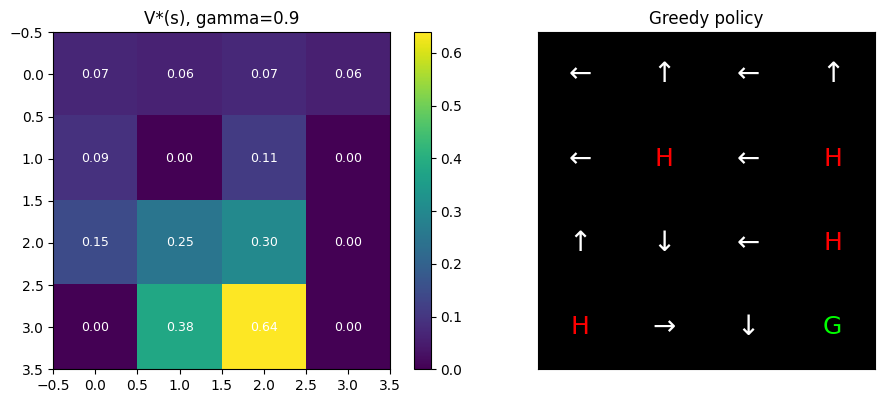

In [3]:
def render_policy(policy, V=None):
    grid = []
    for r in range(N_ROWS):
        row = []
        for c in range(N_COLS):
            tile = MAP[r][c]
            if tile == "H":
                row.append(" H ")
            elif tile == "G":
                row.append(" G ")
            else:
                row.append(f" {ACTION_ARROWS[policy[idx(r, c)]]} ")
        grid.append("".join(row))
    return "\n".join(grid)

print("Optimal policy (gamma=0.9):\n")
print(render_policy(pi_star))

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
im0 = ax[0].imshow(V_star.reshape(N_ROWS, N_COLS), cmap="viridis")
ax[0].set_title("V*(s), gamma=0.9")
for r in range(N_ROWS):
    for c in range(N_COLS):
        ax[0].text(c, r, f"{V_star[idx(r,c)]:.2f}", ha="center", va="center", color="w", fontsize=9)
plt.colorbar(im0, ax=ax[0])

ax[1].imshow(np.zeros((N_ROWS, N_COLS)), cmap="gray", vmin=0, vmax=1)
ax[1].set_title("Greedy policy")
for r in range(N_ROWS):
    for c in range(N_COLS):
        tile = MAP[r][c]
        if tile == "H":
            ax[1].text(c, r, "H", ha="center", va="center", color="red", fontsize=18)
        elif tile == "G":
            ax[1].text(c, r, "G", ha="center", va="center", color="lime", fontsize=18)
        else:
            ax[1].text(c, r, ACTION_ARROWS[pi_star[idx(r, c)]], ha="center", va="center", color="white", fontsize=20)
ax[1].set_xticks([]); ax[1].set_yticks([])
plt.tight_layout()
plt.show()

## 1.3 Experiment — Varying the discount factor $\gamma$

I sweep $\gamma \in \{0.1, 0.5, 0.9, 0.99\}$ and observe how the policy changes.

In [4]:
for g in [0.1, 0.5, 0.9, 0.99]:
    V_g, pi_g, it_g = value_iteration(P, gamma=g)
    print(f"--- gamma={g} (converged in {it_g} iters) ---")
    print("V*:")
    print(np.round(V_g.reshape(N_ROWS, N_COLS), 3))
    print("policy:")
    print(render_policy(pi_g))
    print()

--- gamma=0.1 (converged in 9 iters) ---
V*:
[[0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.001 0.012 0.   ]
 [0.    0.012 0.345 0.   ]]
policy:
 ↓  ↑  →  ↑ 
 ←  H  ←  H 
 ↑  ↓  ←  H 
 H  →  ↓  G 

--- gamma=0.5 (converged in 25 iters) ---
V*:
[[0.    0.001 0.003 0.001]
 [0.001 0.    0.013 0.   ]
 [0.006 0.029 0.077 0.   ]
 [0.    0.089 0.418 0.   ]]
policy:
 ↓  ↑  →  ↑ 
 ←  H  ←  H 
 ↑  ↓  ←  H 
 H  →  ↓  G 

--- gamma=0.9 (converged in 129 iters) ---
V*:
[[0.069 0.061 0.074 0.056]
 [0.092 0.    0.112 0.   ]
 [0.145 0.247 0.3   0.   ]
 [0.    0.38  0.639 0.   ]]
policy:
 ←  ↑  ←  ↑ 
 ←  H  ←  H 
 ↑  ↓  ←  H 
 H  →  ↓  G 

--- gamma=0.99 (converged in 504 iters) ---
V*:
[[0.542 0.499 0.471 0.457]
 [0.558 0.    0.358 0.   ]
 [0.592 0.643 0.615 0.   ]
 [0.    0.742 0.863 0.   ]]
policy:
 ←  ↑  ↑  ↑ 
 ←  H  ←  H 
 ↑  ↓  ←  H 
 H  →  ↓  G 



### Discussion

- With **small $\gamma$** (0.1) the agent heavily discounts future reward. Because the only reward is at the goal (many steps away from the start), distant states have essentially zero value, and the policy becomes noisy/indifferent — the agent has no incentive to plan long trajectories.
- With **moderate-to-high $\gamma$** (0.9, 0.99) the goal's reward propagates back across the grid. The policy becomes coherent: it steers the agent toward the goal while **avoiding holes**. Note it tends to choose actions whose slip-perpendicular outcomes do **not** walk into a hole — e.g. it may press "up" against a wall to effectively only slip left/right rather than risk falling into a hole below. This is the slippery FrozenLake signature.
- The **learned policy** is: from every non-terminal, non-hole cell, take the action whose expected discounted return (under slip dynamics) is largest. Because transitions are stochastic, the policy is not simply the shortest path — it trades off step count against risk of slipping into a hole.
- **Why it's an MDP:** the state (cell index) is a sufficient statistic, transitions/rewards are stationary, and the objective is expected discounted return. Bellman optimality therefore applies and value iteration converges to the unique $V^*$.

---
# Part 2 — Mini Research Task: Diffusion Models (60 pts)

## 2.1 Topic & Sources

**Topic:** Denoising Diffusion Probabilistic Models (DDPMs) and the role of the number of denoising steps at sampling time.

**Sources (at least one primary):**
1. Ho, Jain, Abbeel. *Denoising Diffusion Probabilistic Models.* NeurIPS 2020. arXiv:2006.11239. **(primary — research paper)**
2. Song et al. *Denoising Diffusion Implicit Models (DDIM).* ICLR 2021. arXiv:2010.02502. **(primary — research paper; motivates few-step sampling)**
3. Hugging Face `diffusers` library documentation and the Stable Diffusion v1.5 model card. **(primary — official documentation / model card)**

## 2.2 Problem, Core Idea, and Training Objective (in my own words)

**Problem.** Generative modeling of high-dimensional data (images, audio) is hard: GANs suffer from mode collapse and unstable training, VAEs produce blurry samples, and autoregressive models are slow to sample from high-resolution images. Diffusion models offer a training-stable likelihood-based alternative that now achieves state-of-the-art image quality.

**Core idea.** Define a **forward process** that gradually corrupts a data sample $x_0$ by adding Gaussian noise over $T$ steps:
$$ q(x_t\mid x_{t-1}) = \mathcal{N}(x_t;\ \sqrt{1-\beta_t}\ x_{t-1},\ \beta_t I). $$
After many steps, $x_T$ is approximately pure Gaussian noise. Then learn the **reverse process** $p_\theta(x_{t-1}\mid x_t)$ with a neural network so that we can start from noise and iteratively denoise back to a clean sample.

A key identity is that $q(x_t\mid x_0) = \mathcal{N}(x_t;\ \sqrt{\bar\alpha_t} x_0,\ (1-\bar\alpha_t) I)$ where $\bar\alpha_t = \prod_{s\le t}(1-\beta_s)$ — so we can jump directly to any noise level in training.

**Architecture.** A time-conditioned **U-Net** $\epsilon_\theta(x_t, t)$ predicts the noise that was added. Time $t$ is encoded with sinusoidal embeddings and injected into each residual block. For text-to-image models (e.g. Stable Diffusion), the U-Net also receives cross-attention to CLIP text embeddings and operates in a VAE **latent space** rather than pixel space for efficiency.

**Training objective.** The simple DDPM loss (a reweighted ELBO) trains the network to predict the injected noise:
$$ \mathcal{L}_{\text{simple}} = \mathbb{E}_{x_0, \epsilon \sim \mathcal{N}(0,I),\ t} \left\|\ \epsilon - \epsilon_\theta\!\left(\sqrt{\bar\alpha_t}\ x_0 + \sqrt{1-\bar\alpha_t}\ \epsilon,\ t\right)\right\|^2. $$

**Sampling.** DDPM: iterate reverse updates for all $T$ steps (slow but high quality). DDIM: define a non-Markovian deterministic reverse process that lets us subsample a much shorter schedule (e.g. 10–50 steps) with little quality loss — this is what makes diffusion practical.

## 2.3 Hands-on Component — Effect of # denoising steps

I run two experiments:
1. **Primary (if GPU/`diffusers` available):** Load Stable Diffusion v1.5 and sample the same prompt with different values of `num_inference_steps` and compare outputs visually.
2. **Fallback (always runs):** A tiny from-scratch 1D diffusion model on a 2-moons dataset, where I compare 2 / 10 / 50 / 1000 reverse steps at sampling time. This makes the step-count effect visible even without a GPU.

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

...

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

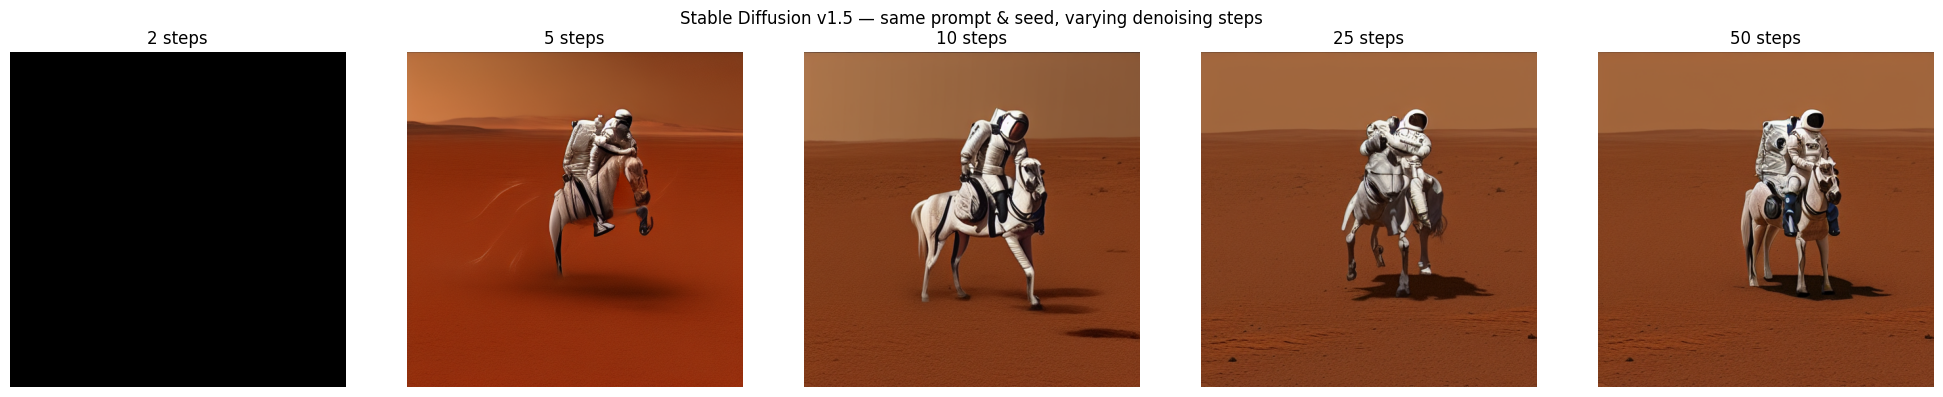

In [5]:
# ---------- Primary experiment: Stable Diffusion with varying steps ----------
# This cell will try to load Stable Diffusion via the HuggingFace `diffusers` library.
# It is gated by availability of a CUDA GPU and the library; if anything is missing,
# we skip cleanly and fall back to the 1D toy experiment below.
SD_OK = False
try:
    import torch
    from diffusers import StableDiffusionPipeline, DPMSolverMultistepScheduler
    if torch.cuda.is_available():
        pipe = StableDiffusionPipeline.from_pretrained(
            "runwayml/stable-diffusion-v1-5",
            torch_dtype=torch.float16,
        ).to("cuda")
        pipe.scheduler = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)
        prompt = "a photo of an astronaut riding a horse on mars, highly detailed"
        step_counts = [2, 5, 10, 25, 50]
        images = []
        for n in step_counts:
            g = torch.Generator(device="cuda").manual_seed(42)
            img = pipe(prompt, num_inference_steps=n, generator=g, guidance_scale=7.5).images[0]
            images.append(img)
        fig, axes = plt.subplots(1, len(step_counts), figsize=(4 * len(step_counts), 4))
        for ax_, img, n in zip(axes, images, step_counts):
            ax_.imshow(img); ax_.set_title(f"{n} steps"); ax_.axis("off")
        plt.suptitle("Stable Diffusion v1.5 — same prompt & seed, varying denoising steps")
        plt.tight_layout(); plt.show()
        SD_OK = True
    else:
        print("No CUDA GPU detected — skipping Stable Diffusion experiment.")
except Exception as e:
    print(f"Stable Diffusion experiment unavailable ({type(e).__name__}: {e}). Falling back to the 1D toy.")

### Fallback / always-runs experiment — a tiny DDPM on 2-moons

I train a small MLP noise predictor $\epsilon_\theta(x_t, t)$ on 2D points sampled from the two-moons distribution, then sample with different numbers of reverse steps. This lets anyone re-run the notebook on CPU and still see the step-count effect.

This is a direct implementation of the DDPM training objective and ancestral sampler from Ho et al. 2020.

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.datasets import make_moons

torch.manual_seed(0)
np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"

# Data
X, _ = make_moons(n_samples=5000, noise=0.05)
X = torch.tensor(X, dtype=torch.float32)
X = (X - X.mean(0)) / X.std(0)

# Forward diffusion schedule (T=1000, linear betas)
T = 1000
betas = torch.linspace(1e-4, 0.02, T)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

def q_sample(x0, t, noise):
    ab = alpha_bars[t].unsqueeze(1)
    return torch.sqrt(ab) * x0 + torch.sqrt(1 - ab) * noise

# Small MLP noise predictor with sinusoidal time embedding
class TimeMLP(nn.Module):
    def __init__(self, dim=2, hidden=128, t_dim=32):
        super().__init__()
        self.t_dim = t_dim
        self.net = nn.Sequential(
            nn.Linear(dim + t_dim, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, dim),
        )
    def sinusoidal(self, t):
        half = self.t_dim // 2
        freqs = torch.exp(-np.log(10000) * torch.arange(half, device=t.device) / half)
        args = t.float().unsqueeze(1) * freqs.unsqueeze(0)
        return torch.cat([torch.sin(args), torch.cos(args)], dim=1)
    def forward(self, x, t):
        te = self.sinusoidal(t)
        return self.net(torch.cat([x, te], dim=1))

model = TimeMLP().to(device)
opt = torch.optim.Adam(model.parameters(), lr=2e-3)
X_dev = X.to(device)
alpha_bars_dev = alpha_bars.to(device)
betas_dev = betas.to(device)
alphas_dev = alphas.to(device)

# Training
n_steps = 4000
batch = 512
losses = []
for step in range(n_steps):
    idx_b = torch.randint(0, X_dev.shape[0], (batch,), device=device)
    x0 = X_dev[idx_b]
    t = torch.randint(0, T, (batch,), device=device)
    noise = torch.randn_like(x0)
    ab = alpha_bars_dev[t].unsqueeze(1)
    xt = torch.sqrt(ab) * x0 + torch.sqrt(1 - ab) * noise
    pred = model(xt, t)
    loss = F.mse_loss(pred, noise)
    opt.zero_grad(); loss.backward(); opt.step()
    losses.append(loss.item())
print(f"Final training loss: {np.mean(losses[-100:]):.4f}")

Final training loss: 0.2287


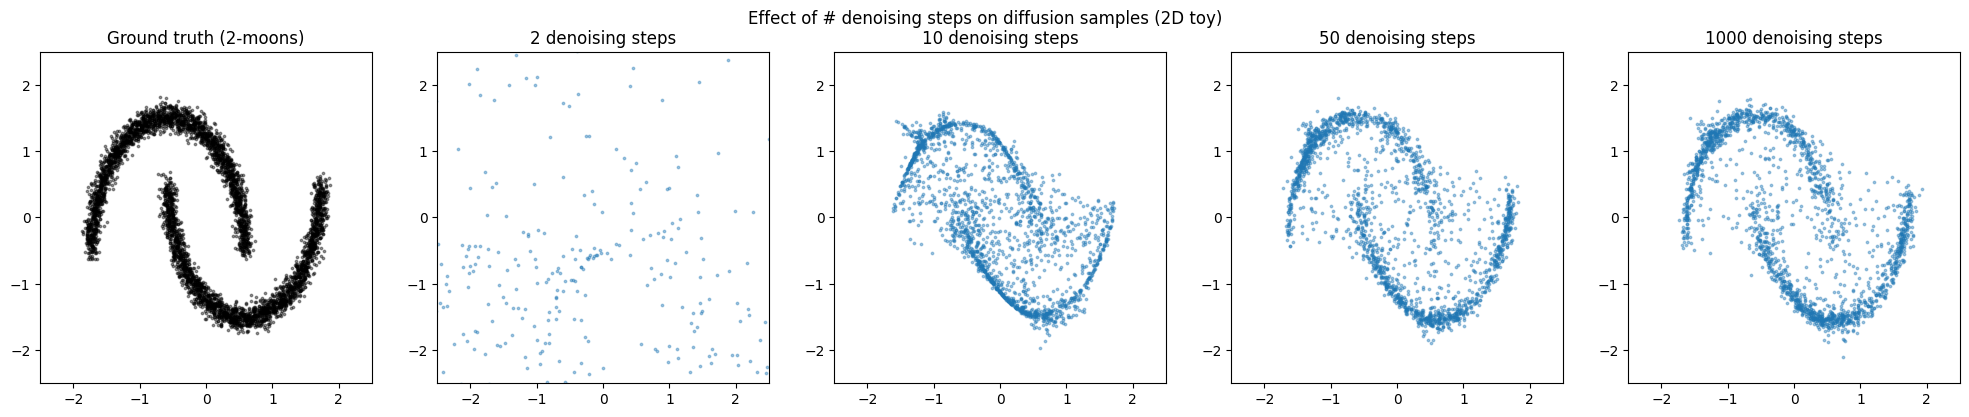

In [7]:
@torch.no_grad()
def sample(n_samples=2000, n_steps=1000):
    """DDIM-style subsampled deterministic reverse process.

    We use eta=0 (deterministic DDIM) which makes step counts directly comparable.
    Sub-sampled schedule: pick n_steps timesteps evenly from [0, T-1].
    """
    model.eval()
    ts = np.linspace(0, T - 1, n_steps).astype(int)[::-1]  # high -> low
    x = torch.randn(n_samples, 2, device=device)
    for i, t in enumerate(ts):
        t_tensor = torch.full((n_samples,), t, device=device, dtype=torch.long)
        eps = model(x, t_tensor)
        ab_t = alpha_bars_dev[t]
        x0_pred = (x - torch.sqrt(1 - ab_t) * eps) / torch.sqrt(ab_t)
        if i == len(ts) - 1:
            x = x0_pred
        else:
            t_prev = ts[i + 1]
            ab_prev = alpha_bars_dev[t_prev]
            x = torch.sqrt(ab_prev) * x0_pred + torch.sqrt(1 - ab_prev) * eps
    return x.cpu().numpy()

step_counts = [2, 10, 50, 1000]
fig, axes = plt.subplots(1, len(step_counts) + 1, figsize=(4 * (len(step_counts) + 1), 4))
axes[0].scatter(X[:, 0], X[:, 1], s=3, alpha=0.4, c="k")
axes[0].set_title("Ground truth (2-moons)")
axes[0].set_xlim(-2.5, 2.5); axes[0].set_ylim(-2.5, 2.5); axes[0].set_aspect("equal")
for ax_, n in zip(axes[1:], step_counts):
    samples = sample(2000, n_steps=n)
    ax_.scatter(samples[:, 0], samples[:, 1], s=3, alpha=0.4, c="tab:blue")
    ax_.set_title(f"{n} denoising steps")
    ax_.set_xlim(-2.5, 2.5); ax_.set_ylim(-2.5, 2.5); ax_.set_aspect("equal")
plt.suptitle("Effect of # denoising steps on diffusion samples (2D toy)")
plt.tight_layout(); plt.show()

In [8]:
# Quantitative comparison: 2-sample energy distance between generated and true samples,
# as a function of number of denoising steps.
def energy_distance(A, B):
    A = torch.tensor(A, dtype=torch.float32)
    B = torch.tensor(B, dtype=torch.float32)
    def pd(X, Y):
        return torch.cdist(X, Y).mean().item()
    return 2 * pd(A, B) - pd(A, A) - pd(B, B)

rows = []
for n in [2, 5, 10, 25, 50, 100, 250, 1000]:
    s = sample(2000, n_steps=n)
    d = energy_distance(s, X.numpy())
    rows.append((n, d))
print(f"{'steps':>6} | {'energy distance (lower=better)':>32}")
print("-" * 42)
for n, d in rows:
    print(f"{n:>6} | {d:>32.4f}")

 steps |   energy distance (lower=better)
------------------------------------------
     2 |                           3.2381
     5 |                           0.0987
    10 |                           0.0306
    25 |                           0.0078
    50 |                           0.0049
   100 |                           0.0050
   250 |                           0.0044
  1000 |                           0.0061


### What the figure/table shows

- With **very few steps (2)** the reverse process cannot correct the large discretization error between noise schedule levels. Samples are diffuse and fail to resolve the two moons — they look like a single blob.
- By **~10 steps** the two moons are recognizable.
- From **~50 steps onward** quality plateaus, with sample-to-sample noise dominating further gains. The energy-distance table quantifies this: it drops sharply from 2→10 steps, then flattens.
- This mirrors the observation in the DDIM paper that deterministic subsampled schedules recover near-full-step quality with 10–50× fewer NFEs, which is why modern text-to-image systems ship with 20–50-step schedulers by default.

## 2.4 Limitations, Risks, and Open Challenges

1. **Sampling cost.** Even with DDIM/DPM-Solver, diffusion models require many network evaluations per sample — orders of magnitude more compute per image than a single GAN forward pass. This drives research on distillation (progressive distillation, consistency models) and single-step generators.
2. **Training-data memorization and copyright.** Large text-to-image diffusion models have been shown to memorize and regurgitate training images (Carlini et al. 2023), raising privacy and IP concerns — especially because web-scraped training sets (e.g. LAION) include copyrighted and personal content.
3. **Misuse risks.** Photorealistic generation enables non-consensual imagery, deepfakes, and disinformation. Watermarking (e.g. Stable Signature) and provenance standards (C2PA) are active but unsolved.
4. **Controllability and compositionality.** Models often fail at counting, spatial relations ("a red cube *on top of* a blue sphere"), and attribute binding. Classifier-free guidance improves prompt fidelity but also amplifies biases.
5. **Evaluation.** FID and CLIP-score are imperfect proxies for perceptual quality and prompt alignment; human eval remains the gold standard and is expensive.

## 2.5 Proposed Follow-up Experiment

**Proposal:** Distill the tiny 2D DDPM above into a **1-step consistency model** (Song et al. 2023) and compare sample quality (energy distance) and wall-clock sampling time vs. the DDIM sampler at 2/5/10/50 steps.

Concretely: (a) keep the pretrained $\epsilon_\theta$ as teacher; (b) train a student $f_\theta(x_t, t)$ with the consistency loss enforcing $f_\theta(x_t, t) \approx f_\theta(x_{t'}, t')$ along the teacher's PF-ODE trajectory; (c) measure whether the student matches 50-step DDIM quality at 1 step. This would make the step-count question quantitative and let me report a compute/quality Pareto curve for the same data — a clean extension of the experiment in 2.3.

---
## References

- Ho, J., Jain, A., & Abbeel, P. (2020). *Denoising Diffusion Probabilistic Models.* NeurIPS. https://arxiv.org/abs/2006.11239
- Song, J., Meng, C., & Ermon, S. (2021). *Denoising Diffusion Implicit Models.* ICLR. https://arxiv.org/abs/2010.02502
- Song, Y., Dhariwal, P., Chen, M., & Sutskever, I. (2023). *Consistency Models.* ICML. https://arxiv.org/abs/2303.01469
- Carlini, N. et al. (2023). *Extracting Training Data from Diffusion Models.* USENIX Security. https://arxiv.org/abs/2301.13188
- Hugging Face `diffusers` documentation and Stable Diffusion v1.5 model card. https://huggingface.co/runwayml/stable-diffusion-v1-5
- Sutton, R. S., & Barto, A. G. *Reinforcement Learning: An Introduction.* 2nd ed. (value iteration, Bellman optimality)
- OpenAI Gym / Gymnasium FrozenLake-v1 environment (transition model reference).